In [1]:
from collections import defaultdict

import xarray as xa
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.ndimage import distance_transform_edt
from tqdm.notebook import tqdm
import seaborn as sns

def get_gridded_deformation(u, v):
    dudx = np.diff(u, axis=1)[1:, :]
    dudy = np.diff(u, axis=0)[:, 1:]
    dvdx = np.diff(v, axis=1)[1:, :]
    dvdy = np.diff(v, axis=0)[:, 1:]
    return dudx, dudy, dvdx, dvdy

def get_deformation_components(u, v):
    dudx, dudy, dvdx, dvdy = get_gridded_deformation(u, v)
    e1 = dudx + dvdy
    e2 = np.hypot(dudx - dvdy, dudy + dvdx)
    e3 = dvdx - dudy
    return np.array([e1, e2, e3, np.hypot(e1, e2)])

In [2]:
with xa.open_dataset('/data1/antonk/tmp/Moorings_2006m02_NXV2-006.nc') as n6:
    u6 = n6['siu'].values
    v6 = n6['siv'].values
    nlat = n6.latitude.values
    nlon = n6.longitude.values

with xa.open_dataset('/data1/antonk/tmp/Moorings_2006m02_NXV2-008.nc') as n8:
    u8 = n8['siu'].values
    v8 = n8['siv'].values


In [3]:
proj = ccrs.NorthPolarStereo(true_scale_latitude=60, central_longitude=-45)
n_xy = proj.transform_points(ccrs.PlateCarree(), nlon, nlat)
n_x = n_xy[0,:,0]
n_y = n_xy[:,0,1]

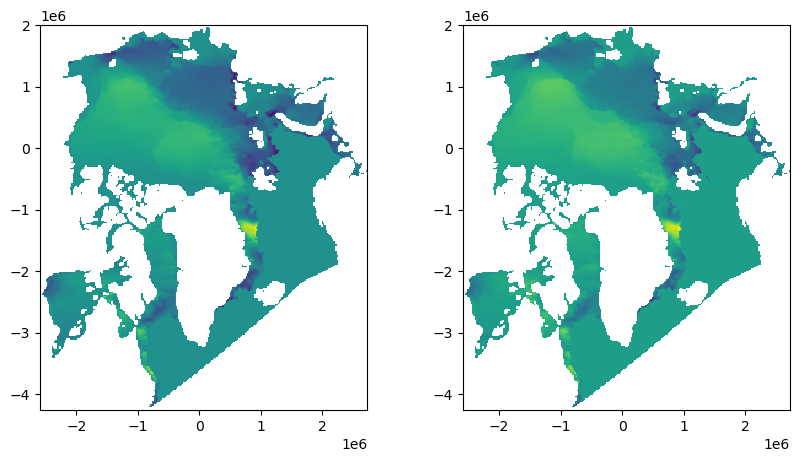

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(u6[0], extent=(n_x[0], n_x[-1], n_y[0], n_y[-1]), origin='lower')
ax[1].imshow(u8[0], extent=(n_x[0], n_x[-1], n_y[0], n_y[-1]), origin='lower')
plt.show()

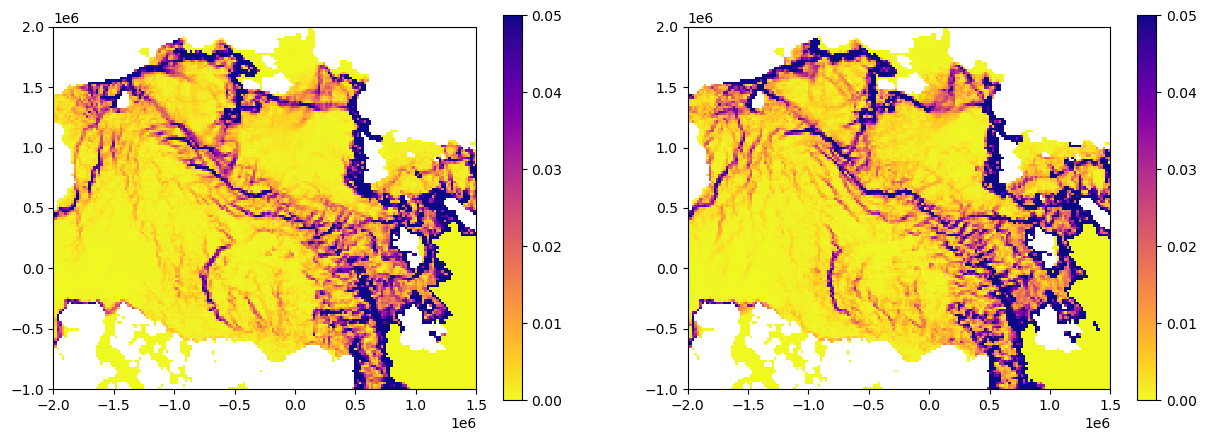

In [5]:
eee6 = get_deformation_components(u6[0], v6[0])
eee8 = get_deformation_components(u8[0], v8[0])

kwargs = dict(
    clim=[0, 0.05],
    cmap='plasma_r',
    interpolation='nearest',
    extent=(n_x[0], n_x[-1], n_y[0], n_y[-1]),
    origin='lower'
)

fig, axs = plt.subplots(1, 2, figsize=(15, 10))
imsh0 = axs[0].imshow(eee6[3], **kwargs)
imsh1 = axs[1].imshow(eee8[3], **kwargs)
plt.colorbar(imsh0, ax=axs[0], shrink=0.5)
plt.colorbar(imsh1, ax=axs[1], shrink=0.5)
for ax in axs:
    ax.set_xlim(-2e6, 1.5e6)
    ax.set_ylim(-1e6, 2e6)
plt.show()


In [6]:
e6all = defaultdict(list)
e8all = defaultdict(list)
steps = [1,2,3,4,5]

for t in tqdm(range(0, u6.shape[0])):
    for stp in steps:
        eee6 = get_deformation_components(u6[t][::stp, ::stp], v6[t][::stp, ::stp]) / stp ** 2
        eee8 = get_deformation_components(u8[t][::stp, ::stp], v8[t][::stp, ::stp]) / stp ** 2
        distance = distance_transform_edt(np.isfinite(u6[t][::stp, ::stp]))[1:, 1:]
        gpi = (distance > 10) * (eee6[3] > 0) * (eee8[3] > 0)
        e6all[stp].append(eee6[3][gpi])
        e8all[stp].append(eee8[3][gpi])

for stp in steps:
    e6all[stp] = np.concatenate(e6all[stp])
    e8all[stp] = np.concatenate(e8all[stp])


  0%|          | 0/112 [00:00<?, ?it/s]

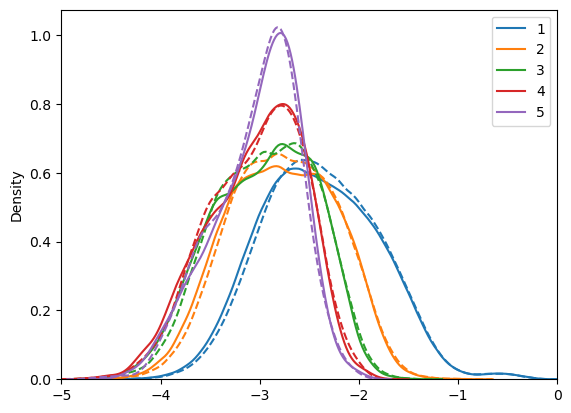

In [7]:
for stp in steps:
    p1 = sns.kdeplot(np.log10(e6all[stp]), label=stp)
    sns.kdeplot(np.log10(e8all[stp]), color=p1.get_lines()[-1].get_color(), linestyle='--')
plt.legend()
plt.xlim([-5, 0])
plt.show()

/tmp/ipykernel_573995/2865732822.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


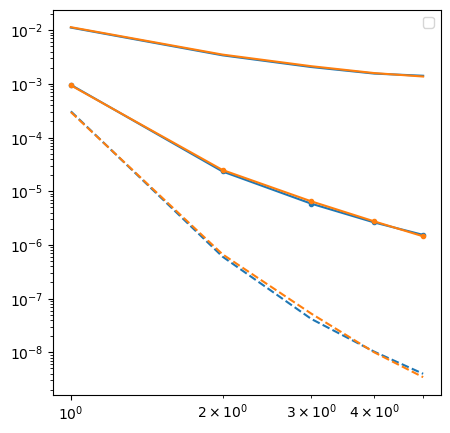

In [8]:
from scipy.stats import moment, skew, kurtosis

datas = [e6all, e8all]
labels = ['e6', 'e8']
# Plot the moments against steps
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

for data, label in zip(datas, labels):
    # Initialize lists to store the moments
    means = []
    variances = []
    skewnesses = []

    # Compute the moments for each step
    for stp in steps:
        d = data[stp]
        means.append(np.mean(d))
        variances.append(moment(d, moment=2))
        skewnesses.append(moment(d, moment=3))

    l0 = axs.loglog(steps, means, '-')
    axs.loglog(steps, variances, '.-', color=l0[0].get_color())
    axs.loglog(steps, skewnesses, '--', color=l0[0].get_color())
plt.legend()
plt.show()

In [ ]:
means